In [1]:
from cmb_lensing.simulate import *
from cmb_lensing.statistics import *
from cmb_lensing.util import *
from cmb_lensing.wiener_filter import *
from cmb_lensing.map_joint import *
from cmb_lensing.lense_flow import *
from cmb_lensing.gradients import *

In [2]:
#Generate an IP data set
data_set = load_sim(nside = 128, #Number of pixels per map side in real space
                    theta_pix = 2.5, #Arcminutes per pixel
                    pol = "I", #Specify IP for temperature and E + B Modes, I for temp only, or P for E + B only
                    master_seed = 67, #Specify a seed for reproduceable results
                    uk_arcmin_t = 5) #Noise level in data fields

In [5]:
field_predict, phi_predict = map_joint(data_set, num_steps = 30)

In [7]:
delensed_field = fourier(lense_flow(map(data_set.lensed_field), map(phi_predict), direction = INVERSE_LENSE))

In [8]:
cf_delensed_exp = jnp.conj(delensed_field.scalar_matrix) * delensed_field.scalar_matrix * get_fourier_weights(delensed_field.scalar_matrix.shape)

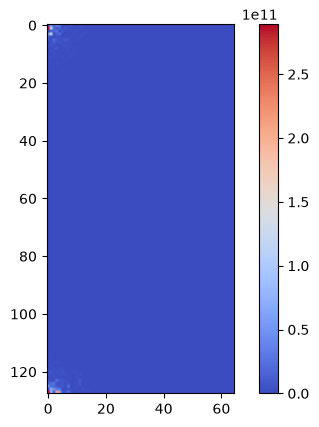

In [13]:
plt.figure()
plt.imshow(jnp.abs(cf_delensed_exp), cmap = "coolwarm")
plt.colorbar()
plt.show()

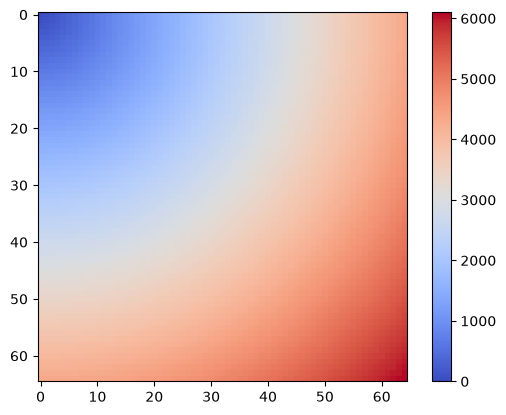

In [12]:
ell_grid, _ = gen_ell_grid(nside, theta_pix)
plt.figure()
plt.imshow(ell_grid[0:65][:], cmap = "coolwarm")
plt.colorbar()
plt.show()

In [13]:
print(ell_grid[-1][-1])

4320.52731156742


In [ ]:
pol = "I"
master_seed = 42
ombh2 = 0.0224567
omch2 = 0.118489
theta_MC_100 = 0.0104098
As = jnp.exp(3.043) * 1e-10
l_knee = 0
lmax = 4000
ns = 0.968602

data_set = load_sim(nside, theta_pix, pol, master_seed, uk_arcmin_t = noise_level, H0 = None,
                    ombh2 = ombh2, omch2 = omch2, cosmomc_theta = theta_MC_100 / 100,
                    r = 0.0, mnu = DEFAULT_MNU, tau = DEFAULT_TAUREIO, As = As,
                    nt = 0, ns = ns, lmax = lmax, l_knee = l_knee,
                    k_pivot = DEFAULT_K_PIVOT, Alens = DEFAULT_A_LENSE, nphi_fac = 2, a_phi = 1)